# 共享验证集上的方法对比

这个 notebook 只使用同一批 `90` 个验证样本，对机器学习方法和 baseline 方法做统一口径对比。

说明：
- `LightPred / CNN / LSTM` 使用完全相同的验证集划分
- `LS / ACF / GPS / QP-GP` 也只保留这同一批 `KIC`
- `ACF` 在这批样本上只有 `N=10` 个有效预测，因此只能作为补充参考

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlepad'] = 10
plt.rcParams['grid.alpha'] = 0.18
plt.rcParams['grid.linestyle'] = ':'

PRED_PATH = Path(r'D:/Dissertation/backup/data/kepler/models/shared_val_method_predictions.csv')
SUMMARY_PATH = Path(r'D:/Dissertation/backup/data/kepler/models/shared_val_method_summary.csv')
shared_df = pd.read_csv(PRED_PATH)
summary_df = pd.read_csv(SUMMARY_PATH)

method_order = ['CNN', 'QP-GP', 'LSTM', 'LightPred', 'GPS', 'LS', 'ACF']
palette = {
    'LightPred': '#4C72B0',
    'CNN': '#55A868',
    'LSTM': '#C44E52',
    'LS': '#64B5CD',
    'ACF': '#DD8452',
    'GPS': '#64B96A',
    'QP-GP': '#8172B2',
}
shared_df.head()

,kic,prot_label,LightPred,CNN,LSTM,LS,ACF,GPS,QP-GP
0,3236788,5.429000,19.197552,6.619698,18.806664,38.826446,5.047107,4.595318,6.848275
1,3327068,4.519000,10.815980,5.805726,19.214401,4.479706,4.495397,3.802676,5.296426
2,3543989,6.816000,15.588225,9.800034,17.160915,38.739825,NaN,32.205686,10.056956
3,3545170,1.154000,14.400917,17.969210,17.056068,34.107974,NaN,34.715719,1.154028
4,3850729,38.751999,12.627522,36.761723,16.524893,39.098074,37.638768,33.262542,38.700846


## 指标汇总

In [2]:
display(
    summary_df.set_index('method').loc[method_order].reset_index().round(4)
)

,method,N,MAE,RMSE,MedianAbsErr,Bias,MedianBias,Frac(<10%),Frac(<20%),Corr
0,CNN,90,6.2329,8.2708,4.1811,-0.8501,0.1248,0.2556,0.4222,0.6168
1,QP-GP,90,3.9749,6.2244,2.4163,3.9163,2.4163,0.3556,0.6667,0.9377
2,LSTM,90,8.4417,10.3349,7.4751,-0.2907,-0.3654,0.1667,0.3444,0.0725
3,LightPred,90,9.3178,11.1357,8.3906,-3.6862,-3.5079,0.1000,0.1778,0.1092
4,GPS,87,10.3768,13.6430,6.7738,7.2035,3.1164,0.1149,0.4713,0.3112
5,LS,90,17.8885,21.4026,20.2242,17.8167,20.2242,0.1778,0.2111,0.2912
6,ACF,10,0.3743,0.5520,0.2308,-0.3743,-0.2308,1.0000,1.0000,0.9998


## Label vs Prediction（同一验证集）

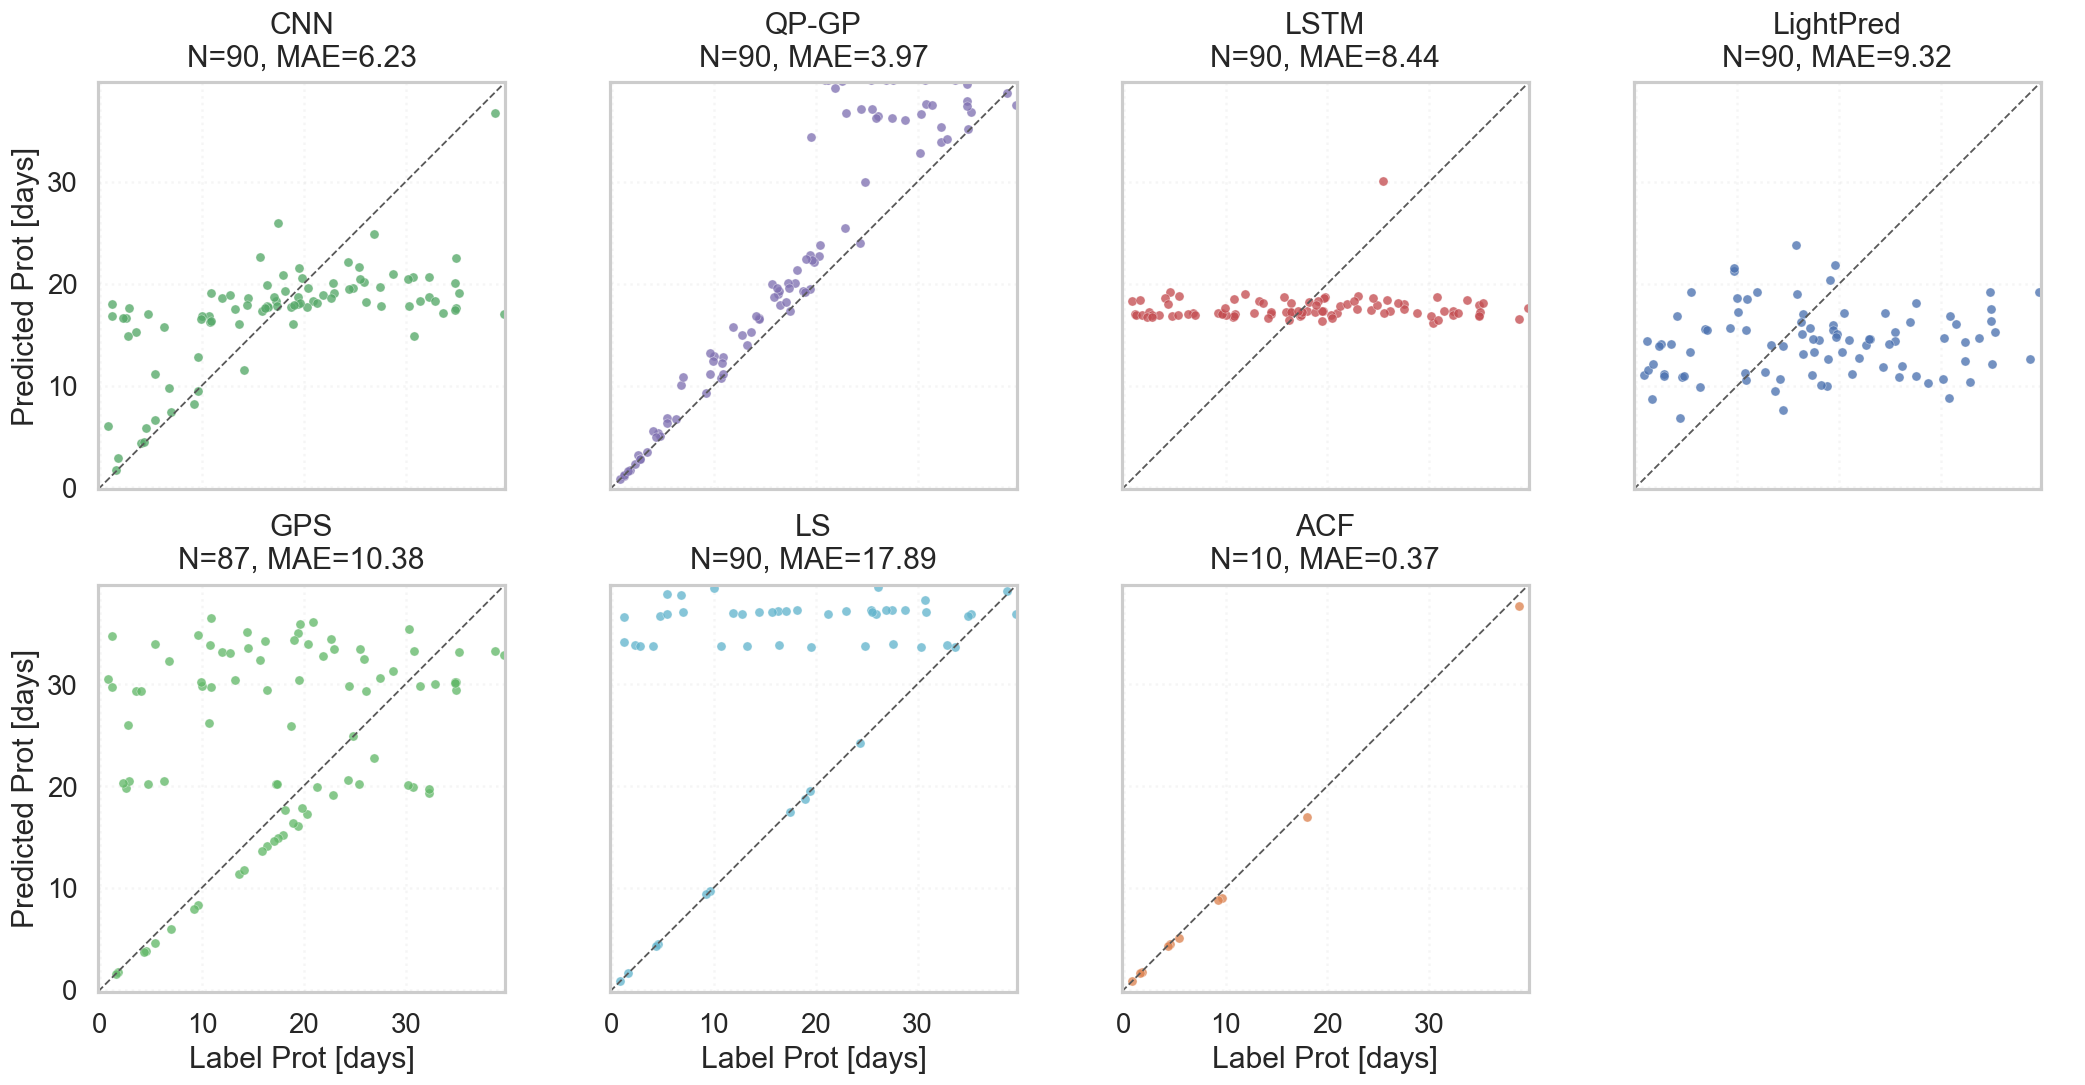

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18.0, 9.2), sharex=True, sharey=True)
axes = axes.ravel()
for ax, method in zip(axes, method_order):
    plot_df = shared_df[['prot_label', method]].replace([np.inf, -np.inf], np.nan).dropna()
    if plot_df.empty:
        ax.axis('off')
        continue
    sns.scatterplot(
        data=plot_df,
        x='prot_label',
        y=method,
        s=30,
        alpha=0.78,
        linewidth=0.25,
        edgecolor='white',
        color=palette[method],
        ax=ax,
    )
    lim_min = min(plot_df['prot_label'].min(), plot_df[method].min())
    lim_max = max(plot_df['prot_label'].max(), plot_df[method].max())
    lims = [lim_min - 1, lim_max + 1]
    ax.plot(lims, lims, linestyle='--', color='0.35', linewidth=1.1)
    row = summary_df[summary_df['method'] == method].iloc[0]
    ax.set_title(f"{method}\nN={int(row['N'])}, MAE={row['MAE']:.2f}")
    ax.set_xlabel('Label Prot [days]')
    ax.set_ylabel('Predicted Prot [days]')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', 'box')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 相对误差 ECDF（同一验证集）

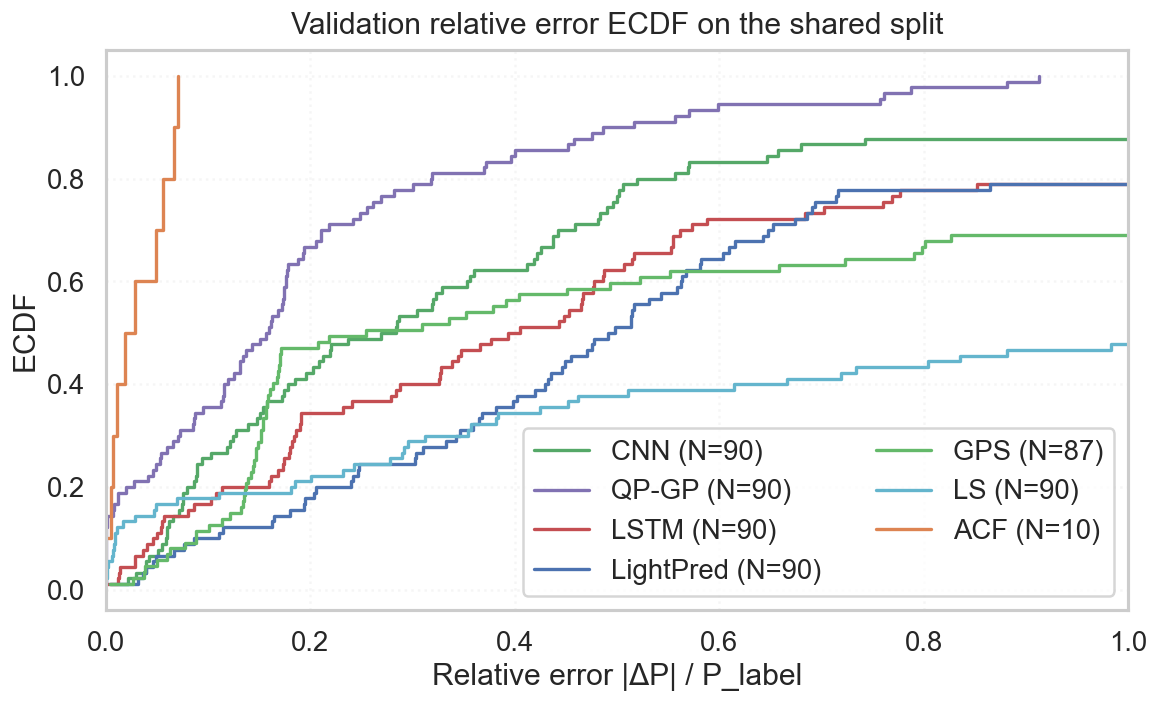

In [4]:
fig, ax = plt.subplots(figsize=(10.0, 6.2))
for method in method_order:
    plot_df = shared_df[['prot_label', method]].replace([np.inf, -np.inf], np.nan).dropna()
    rel = ((plot_df[method] - plot_df['prot_label']).abs() / plot_df['prot_label']).sort_values().to_numpy()
    if len(rel) == 0:
        continue
    y = np.arange(1, len(rel) + 1) / len(rel)
    ax.step(rel, y, where='post', linewidth=2.0, label=f"{method} (N={len(rel)})", color=palette[method])
ax.set_xlim(0, 1.0)
ax.set_xlabel('Relative error |ΔP| / P_label')
ax.set_ylabel('ECDF')
ax.set_title('Validation relative error ECDF on the shared split')
ax.legend(frameon=True, ncol=2)
plt.tight_layout()
plt.show()

## 误差分布

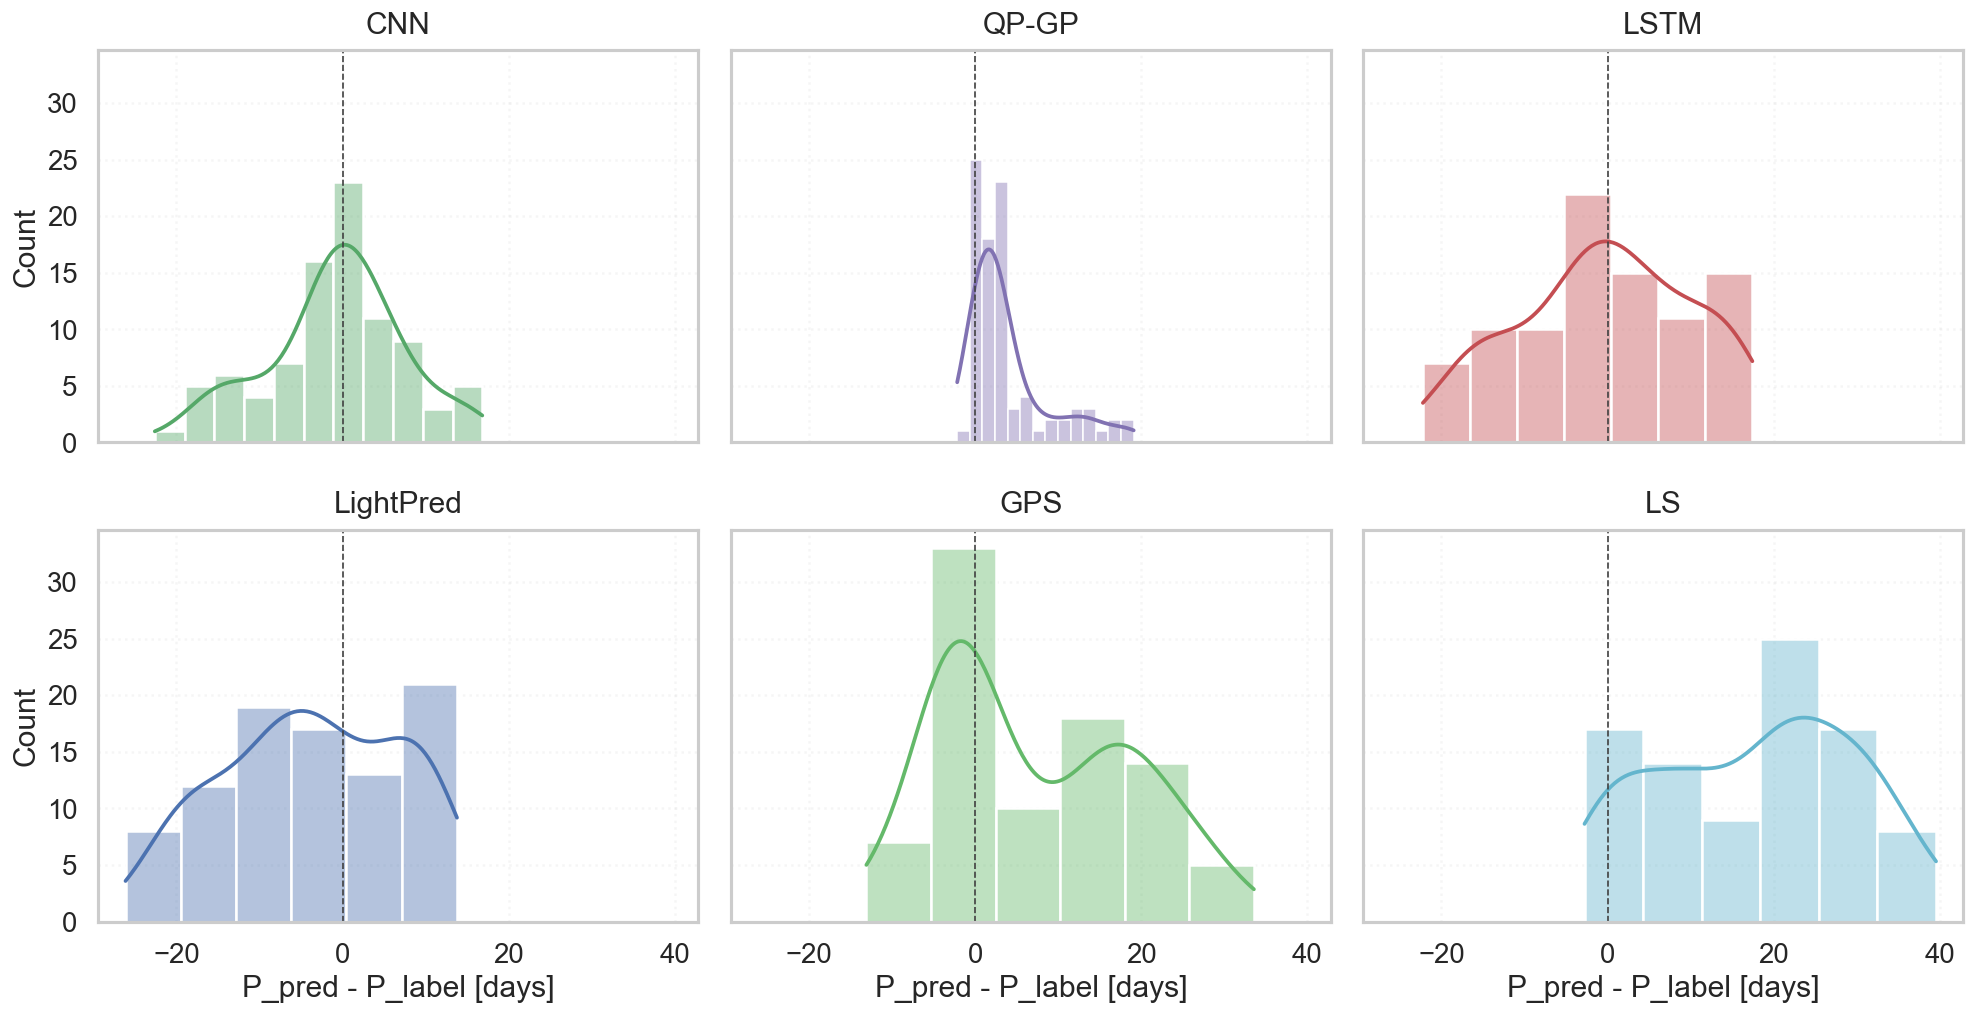

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16.8, 8.8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, method in zip(axes, ['CNN', 'QP-GP', 'LSTM', 'LightPred', 'GPS', 'LS']):
    plot_df = shared_df[['prot_label', method]].replace([np.inf, -np.inf], np.nan).dropna()
    err = plot_df[method] - plot_df['prot_label']
    sns.histplot(err, bins='fd', kde=True, color=palette[method], alpha=0.42, ax=ax)
    ax.axvline(0.0, linestyle='--', linewidth=1.0, color='0.25')
    ax.set_title(method)
    ax.set_xlabel('P_pred - P_label [days]')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 分周期段误差

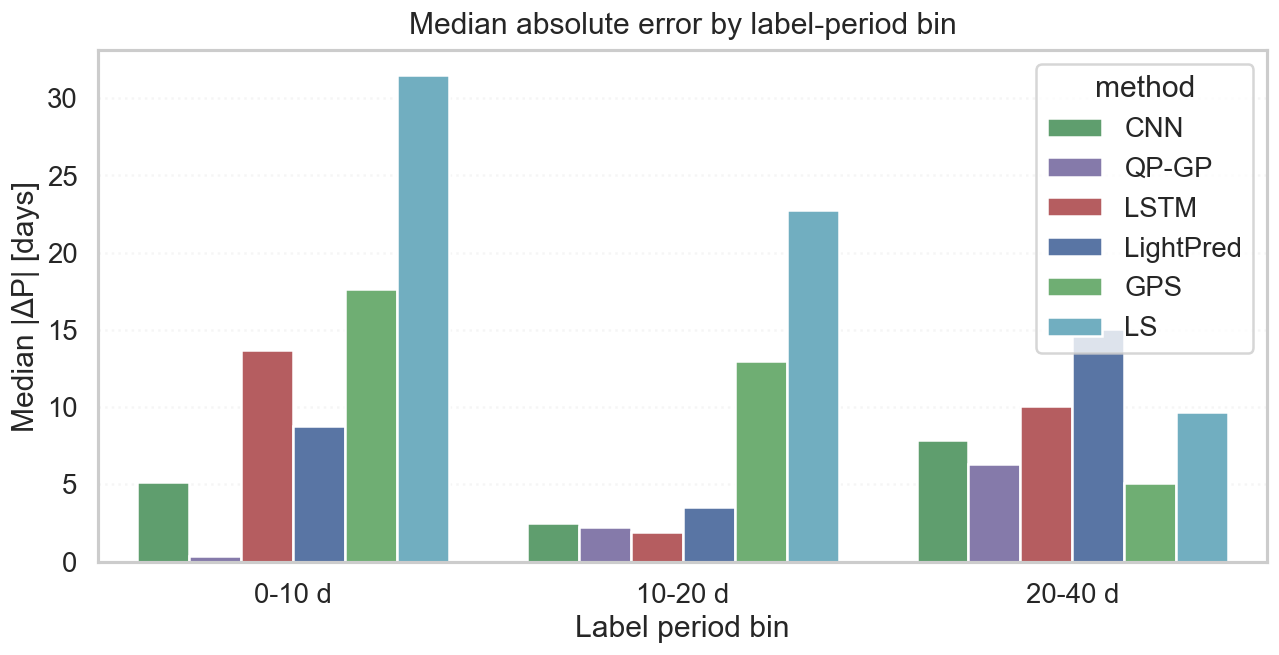

method,CNN,GPS,LS,LSTM,LightPred,QP-GP
period_bin,,,,,,
0-10 d,5.1735,17.6492,31.5131,13.6737,8.7722,0.3788
10-20 d,2.4968,12.9984,22.7739,1.8916,3.5079,2.2231
20-40 d,7.8773,5.0683,9.6813,10.0770,15.0349,6.3370


In [6]:
rows = []
bins = [0, 10, 20, 40.1]
labels = ['0-10 d', '10-20 d', '20-40 d']
for method in ['CNN', 'QP-GP', 'LSTM', 'LightPred', 'GPS', 'LS']:
    plot_df = shared_df[['prot_label', method]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    plot_df['period_bin'] = pd.cut(plot_df['prot_label'], bins=bins, labels=labels, include_lowest=True, right=False)
    plot_df['abs_err'] = (plot_df[method] - plot_df['prot_label']).abs()
    agg = plot_df.groupby('period_bin', observed=False)['abs_err'].median().reset_index()
    agg['method'] = method
    rows.append(agg)
bin_df = pd.concat(rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(11.0, 5.8))
sns.barplot(data=bin_df, x='period_bin', y='abs_err', hue='method', palette=palette, ax=ax)
ax.set_xlabel('Label period bin')
ax.set_ylabel('Median |ΔP| [days]')
ax.set_title('Median absolute error by label-period bin')
plt.tight_layout()
plt.show()

display(bin_df.pivot(index='period_bin', columns='method', values='abs_err').round(4))